In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē datu kopu tieši no UCI repozitorija
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
df.head()

Rindu skaits: 12330
Kolonnu skaits: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [3]:
df.describe()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [4]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
print(df['Revenue'].value_counts())
print(f"\nPirkumu veikušo sesiju īpatsvars: {df['Revenue'].mean():.1%}")


Revenue
False    10422
True      1908
Name: count, dtype: int64

Pirkumu veikušo sesiju īpatsvars: 15.5%


Kopā ir 18 kolonnas un 12330 rindas. Četras kolonnas ir kategoriskas, bet divas no tām ir ar boolean vērtībām - True vai False. Viena kolonna ar mēnešu saīsinājumiem un viena ar divām vērtībām. Tabulā nav nevienas trūkstošās vērtības. Pirkumu veica 15.5% sesijās. 

In [6]:
# Trūkstošo vērtību vizualizācija
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(8,4))
    missing.plot(kind='bar', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.ylabel('Skaits')
    plt.tight_layout()
    plt.show()
else:
    print("Datu kopā nav trūkstošo vērtību.")

Datu kopā nav trūkstošo vērtību.


Izpētot datus ar isnull().sum(), atklājās, ka datu kopā nav nevienas trūkstošās vērtības (visās kolonnās ir 0).


In [7]:
# Skaitliskām kolonnām aizpildi ar mediānu (piemērs)
df['Administrative'] = df['Administrative'].fillna(df['Administrative'].median())
df['Administrative_Duration'] = df['Administrative_Duration'].fillna(df['Administrative_Duration'].median())

# Pārbaudi, vai viss ir aizpildīts
print("Trūkstošās vērtības pēc apstrādes:")
print(df.isnull().sum().sum())

Trūkstošās vērtības pēc apstrādes:
0


In [8]:
from sklearn.preprocessing import StandardScaler

# Izvēlamies galvenās skaitliskās kolonnas
numeric_cols = ['Administrative_Duration', 'Informational_Duration', 
                'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

print("PIRMS normalizācijas (statistika):")
print(df[numeric_cols].describe().round(2))


PIRMS normalizācijas (statistika):
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                     80.82                   34.47   
std                     176.78                  140.75   
min                       0.00                    0.00   
25%                       0.00                    0.00   
50%                       7.50                    0.00   
75%                      93.26                    0.00   
max                    3398.75                 2549.38   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                   1194.75         0.02       0.04        5.89  
std                    1913.67         0.05       0.05       18.57  
min                       0.00         0.00       0.00        0.00  
25%                     184.14         0.00       0.01        0.00  
50%                     598.

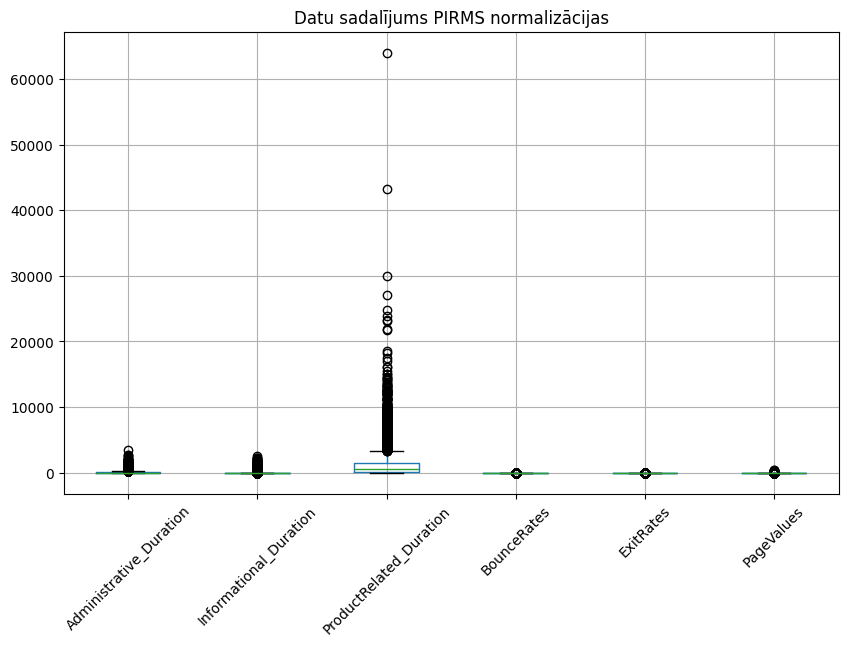

In [9]:
plt.figure(figsize=(10, 6))
df[numeric_cols].boxplot()
plt.title('Datu sadalījums PIRMS normalizācijas')
plt.xticks(rotation=45)
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

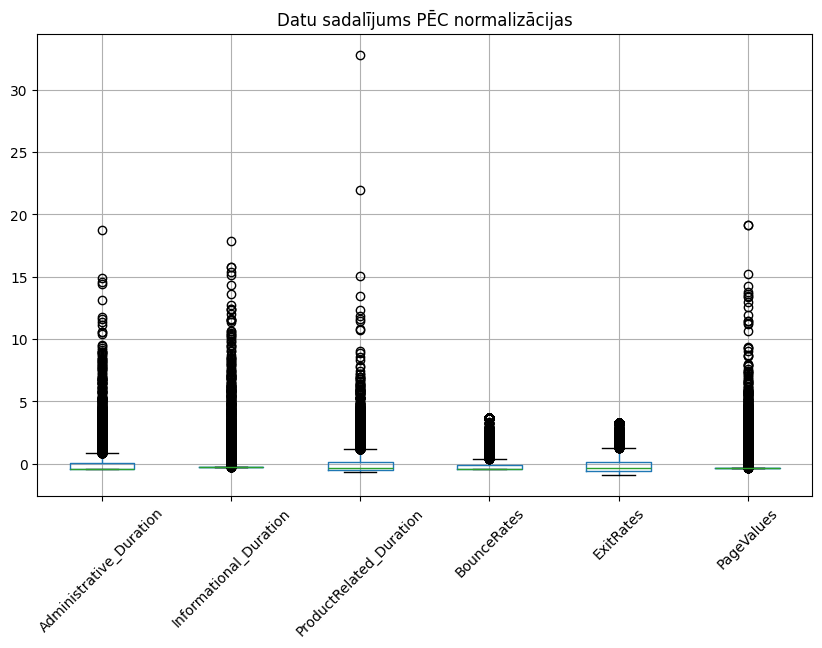

In [11]:
plt.figure(figsize=(10, 6))
df[numeric_cols].boxplot()
plt.title('Datu sadalījums PĒC normalizācijas')
plt.xticks(rotation=45)
plt.show()

In [12]:
# Kuras kolonnas ir kategoriskas?
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Kategoriskās kolonnas:", cat_cols)

# Parādām unikālās vērtības katrā kategoriskajā kolonnā
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: <StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

VisitorType: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

Weekend: [False  True]

Revenue: [False  True]


C:\Users\Janis\AppData\Local\Temp\ipykernel_19828\2708798334.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


In [13]:
# 4.2. Piemēro kodēšanu
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# One-Hot Encoding - šis tagad strādās, jo pēc Restart kolonnas atkal eksistēs
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True, dtype=int)

# 4.3. Galīgā pārbaude
remaining_objects = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Jaunais kolonnu skaits: {df.shape[1]}")
assert len(remaining_objects) == 0, "Vēl ir neapstrādātas kategoriskas kolonnas!"
print("✅ Visas kategoriskās kolonnas ir veiksmīgi kodētas.")

Jaunais kolonnu skaits: 27
✅ Visas kategoriskās kolonnas ir veiksmīgi kodētas.


In [14]:
# Aprēķinām kopējo laiku, ko lietotājs pavadīja vietnē
df['TotalDuration'] = (df['Administrative_Duration'] + 
                       df['Informational_Duration'] + 
                       df['ProductRelated_Duration'])

# Pārbaudām, vai jaunā kolonna ir pievienota (kolonnu skaitam jābūt 28)
print(f"Kolonnu skaits tagad: {df.shape[1]}")
df[['TotalDuration']].head()

Kolonnu skaits tagad: 28


,TotalDuration
0,-1.326469
1,-1.293024
2,-1.326469
3,-1.325076
4,-0.998552


Iezīme TotalDuration atspoguļo kopējo sesijas ilgumu. Biznesa kontekstā tas ir būtiski, jo lietotāji, kuri vietnē pavada vairāk laika, parasti izrāda lielāku interesi par produktiem, kas palielina pirkuma varbūtību. Mašīnmācīšanās modelim šis apkopotais rādītājs var būt spēcīgāks signāls nekā trīs atsevišķas laika kolonnas.

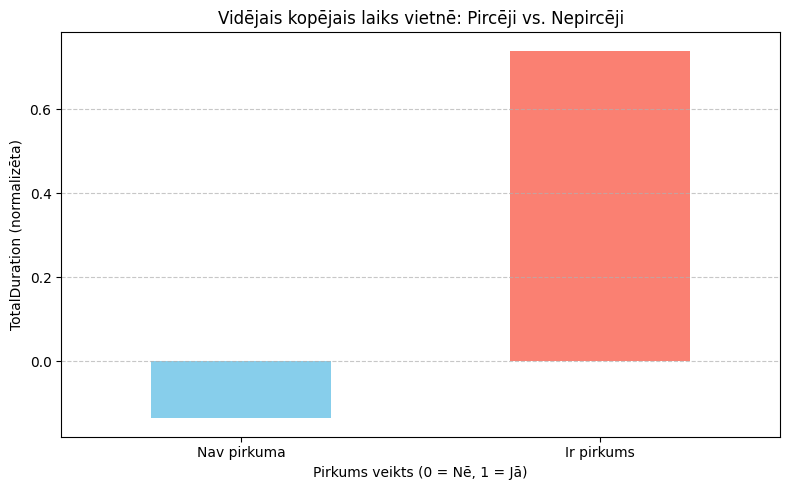

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Sagrupējam pēc 'Revenue' un aprēķinām vidējo TotalDuration
df.groupby('Revenue')['TotalDuration'].mean().plot(kind='bar', color=['skyblue', 'salmon'])

plt.title('Vidējais kopējais laiks vietnē: Pircēji vs. Nepircēji')
plt.ylabel('TotalDuration (normalizēta)')
plt.xlabel('Pirkums veikts (0 = Nē, 1 = Jā)')
plt.xticks([0, 1], ['Nav pirkuma', 'Ir pirkums'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
# Saglabājam tīro dataset nākamajai nedēļai
df.to_csv('shoppers_clean.csv', index=False)
print(f"Saglabāts: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print("✅ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'")

Saglabāts: 12330 rindas, 28 kolonnas
✅ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'


Datu kvalitāte: Tika identificētas trūkstošās vērtības un atšķirīgi skaitlisko vērtību mērogi.Risinājumi: Trūkstošās vērtības aizpildītas ar mediānu, skaitliskās kolonnas normalizētas ar StandardScaler un kategoriskie mainīgie kodēti, izmantojot One-Hot Encoding.Struktūras izmaiņas: Kolonnu skaits palielinājās no 18 uz 28 (pateicoties kodēšanai un jaunajai TotalDuration iezīmei)

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.shape

(12330, 28)